In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [55]:
query = session.query(Feedback).join(Round).filter(
        Feedback.key_name=='job_preferences',
        Round.start_datetime >= datetime(2023, 7, 1))

df = pd.read_sql_query(query.statement, session.connection())

In [56]:
def json_to_series(text):
    keys, values = zip(*[(k, v) for k, v in text['data'].get("Captain", {}).items()])
    return pd.Series(values, index=keys)
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1)

In [57]:
df

,id,datetime,round_id,key_name,key_type,version,json,high,medium,low,never,banned,young,disabled
0,480033,2023-07-01 01:33:51,36358,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,2,1,24,1,24,0
1,479993,2023-07-01 02:19:22,36359,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",2,1,2,23,0,14,0
2,479949,2023-07-01 04:37:00,36360,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",1,0,3,19,2,21,0
3,479903,2023-07-01 06:54:44,36361,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,0,2,9,0,15,0
4,479872,2023-07-01 08:59:18,36362,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,0,0,12,0,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4950,483050,2024-08-10 10:37:46,41396,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,0,2,11,2,14,0
4951,482984,2024-08-10 13:20:03,41397,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,1,3,14,1,15,0
4952,482925,2024-08-10 15:34:15,41398,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",1,1,1,22,1,14,0
4953,482875,2024-08-10 17:52:46,41399,job_preferences,nested tally,1,"{'data': {'Assistant': {'high': 0, 'medium': 0...",0,4,1,27,1,25,0


In [58]:
df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['year'] = df.datetime.dt.year

In [59]:
data = dict()
for pref in ["high", "medium", "low", "never"]:
    datum = df.groupby(['month', 'year'], as_index=False)[pref].mean(numeric_only=True)
    datum['dt']= pd.to_datetime(datum.year.astype(str) + datum.month.astype(str), format='%Y%m')
    data[pref] = datum

# datum = df.groupby(['month', 'year'], as_index=False)["high"].mean(numeric_only=True)
# datum['dt']= pd.to_datetime(datum.year.astype(str) + datum.month.astype(str), format='%Y%m')

In [60]:
data

{'high':     month  year      high         dt
 0       1  2024  0.709333 2024-01-01
 1       2  2024  0.860399 2024-02-01
 2       3  2024  0.650667 2024-03-01
 3       4  2024  0.604396 2024-04-01
 4       5  2024  0.757033 2024-05-01
 5       6  2024  0.616438 2024-06-01
 6       7  2023  0.698701 2023-07-01
 7       7  2024  0.874346 2024-07-01
 8       8  2023  0.816860 2023-08-01
 9       8  2024  0.727273 2024-08-01
 10      9  2023  0.710811 2023-09-01
 11     10  2023  0.577720 2023-10-01
 12     11  2023  0.683784 2023-11-01
 13     12  2023  0.694149 2023-12-01,
 'medium':     month  year    medium         dt
 0       1  2024  1.418667 2024-01-01
 1       2  2024  1.096866 2024-02-01
 2       3  2024  1.250667 2024-03-01
 3       4  2024  0.879121 2024-04-01
 4       5  2024  1.544757 2024-05-01
 5       6  2024  0.660274 2024-06-01
 6       7  2023  1.441558 2023-07-01
 7       7  2024  0.811518 2024-07-01
 8       8  2023  1.537791 2023-08-01
 9       8  2024  1.033058 2024

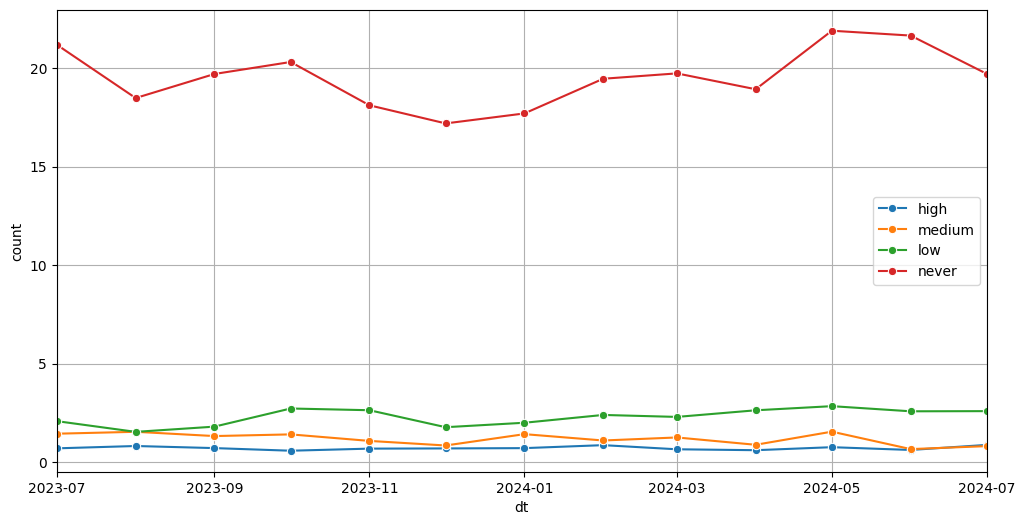

In [62]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
for pref, datum in data.items():
    sns.lineplot(data=datum, x='dt', y=pref, marker='o', label=pref)

ax.set(ylabel='count')
plt.grid()
plt.xlim(date(2023, 7, 1), date(2024, 7, 1))
plt.savefig('cap_avg.png')